In [1]:
# import modules
import pandas as pd
import numpy as np

### Airports Data

The dataset is provided by openflights (https://openflights.org/data, GitHub: https://github.com/jpatokal/openflights)

`Airport ID` : Unique identifier used by OpenFlights for each airport

`Name` : Name of the airport

`City` : Main city served by the airport

`Country` : Country or territory where the airport is located

`IATA` : 3-letter IATA airport code (e.g., ZRH)

`ICAO` : 4-letter ICAO airport code (e.g., LSZH)

`Latitude` : to six significant digits. Negative is South, positive is North (in decimal degrees))

`Longitude` : to six significant digits. Negative is West, positive is East (in decimal degrees)

`Altitude` : Altitude of the airport (in feet)

`Timezone` : Timezone offset from UTC (in hours)

`DST` : Daylight Saving Time rule used by the airport's region

`Tz database timezone` : Timezone in Olson format (e.g., Europe/Zurich)

`Type` : Type of the airport (e.g., airport, station, port)

`Source` : Source of the data (e.g., OurAirports, Legacy, User) 

In [2]:
# columns for flights_df DataFrame
flights_df_cols = ["Airport ID", "Name", "City", "Country", "IATA", "ICAO", "Latitude", 
        "Longitude", "Altitude", "Timezone", "DST", "Tz database timezone", "Type", "Source"]

# read dataset: https://openflights.org/data (GitHub: https://github.com/jpatokal/openflights)
flights_df = pd.read_csv("data/airports-extended.dat", header=None, names=flights_df_cols)

flights_df = flights_df.drop_duplicates(subset="ICAO")

flights_df.head()

,Airport ID,Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz database timezone,Type,Source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports


In [3]:
# columns for routes_df DataFrame 
routes_df_cols = ["Airline", "Airline ID", "Source airport", "Source airport ID",
               "Destination airport", "Destination airport ID", "Codeshare", "Stops", "Equipment"]

# read dataset: https://openflights.org/data (GitHub: https://github.com/jpatokal/openflights)
routes_df = pd.read_csv("data/routes.dat", header=None, names=routes_df_cols)

routes_df.head()

,Airline,Airline ID,Source airport,Source airport ID,Destination airport,Destination airport ID,Codeshare,Stops,Equipment
0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2
2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2
3,2B,410,CEK,2968,KZN,2990,NaN,0,CR2
4,2B,410,CEK,2968,OVB,4078,NaN,0,CR2


### Flights Data

In [4]:
# read dataset: https://www.opdi.aero/flight-list-data (period: from January 2022 to January 2026)

# flights data in January 2022
flight_list_202201_df = pd.read_parquet("data/flight_list/flight_list_202201.parquet", engine="pyarrow")

flight_list_202201_df

,id,icao24,flt_id,dof,adep,ades,adep_p,ades_p,registration,model,typecode,icao_aircraft_class,icao_operator,first_seen,last_seen,version,unix_time
0,8031742745067,4244dd,IZA301,2022-01-20,None,UUDD,,,VQ-BBQ,None,B738,L2J,None,2022-01-20 03:28:25,2022-01-20 04:41:05,v2.0.0,1642649305
1,95435664144720,0a0044,DAH4062,2022-01-06,None,None,None,None,7T-VJV,A330 202,A332,L2J,DAH,2022-01-06 17:20:05,2022-01-06 17:36:40,v2.0.0,1641489605
2,166223829021550,4cafb5,RYR2249,2022-01-17,None,LPPR,,,EI-GSI,None,B738,L2J,None,2022-01-17 09:19:15,2022-01-17 11:10:50,v2.0.0,1642411155
3,182032397209100,a92ddf,UAL121,2022-01-18,LEBL,None,,,N69059,767-424ER,B764,L2J,UAL,2022-01-18 10:07:40,2022-01-18 11:36:05,v2.0.0,1642500460
4,196277043187851,4baa47,THY7NY,2022-01-29,None,LTFM,,LTBA,TC-JRG,A321 231,A321,L2J,THY,2022-01-29 09:54:25,2022-01-29 10:40:00,v2.0.0,1643450065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814035,18446559518107896499,398570,AFR76ST,2022-01-19,EDDN,LFPG,,,F-HBLQ,E190STD,E190,L2J,HOP,2022-01-19 16:42:20,2022-01-19 17:52:00,v2.0.0,1642610540
814036,18446628696267622849,424246,SDM6345,2022-01-10,None,None,None,None,VP-BIQ,A319 111,A319,L2J,SDM,2022-01-10 14:47:55,2022-01-10 16:33:15,v2.0.0,1641826075
814037,18446687645983885697,42413c,VPCHI,2022-01-15,None,EGPF,,,VP-CHI,Gulfstream Aerospace G550,GLF5,L2J,None,2022-01-15 07:51:30,2022-01-15 12:29:35,v2.0.0,1642233090
814038,18446710819872301221,3c6487,DLH1HU,2022-01-11,EDDF,EDDM,,,D-AIDG,A321 231,A321,L2J,DLH,2022-01-11 06:22:45,2022-01-11 07:03:00,v2.0.0,1641882165


In [5]:
flight_list_202201_df = flight_list_202201_df.drop(columns={"adep_p", "ades_p", "version"}).dropna() # drop columns adep_p, ades_p, and version, and remove rows with missing values

flight_list_202201_df.head()

,id,icao24,flt_id,dof,adep,ades,registration,model,typecode,icao_aircraft_class,icao_operator,first_seen,last_seen,unix_time
5,205277703660736,3c5461,DLH836,2022-01-19,EDDF,EKBI,D-AECA,Embraer EMB-190 LR,E190,L2J,DLH,2022-01-19 08:00:25,2022-01-19 09:09:00,1642579225
7,230761165337664,4b1803,SWR48AB,2022-01-24,LFMN,LSZH,HB-JCL,BD-500-1A11 (CS300),BCS3,L2J,SWR,2022-01-24 09:16:10,2022-01-24 10:13:40,1643015770
16,414529853499604,4ac9e7,SAS386D,2022-01-16,ESSA,LSGG,SE-ROG,Airbus A320-251N,A20N,L2J,SAS,2022-01-16 09:24:00,2022-01-16 11:58:10,1642325040
19,445646788153524,4baa6b,THY3CP,2022-01-28,LTFM,LTAE,TC-JSK,A321 231SL,A321,L2J,THY,2022-01-28 14:33:15,2022-01-28 15:20:30,1643380395
23,587955885648262,3c5464,DLH1JR,2022-01-27,EDDF,LIMC,D-AECD,EMB-190 LR,E190,L2J,DLH,2022-01-27 16:56:45,2022-01-27 17:56:45,1643302605


In [6]:
# read dataset: https://openflights.org/data (GitHub: https://github.com/jpatokal/openflights)
airports_df = pd.read_csv("data/airports.dat", header=None)

# columns for airports_df DataFrame
airports_df.columns = ["id", "name", "city", "country", "iata", "icao", "lat", "lon", "alt", "tz", "dst", "tz_db", "type", "source"]

In [7]:
icao_country_df = airports_df[["icao","country"]]
icao_country_df.head(10)

,icao,country
0,AYGA,Papua New Guinea
1,AYMD,Papua New Guinea
2,AYMH,Papua New Guinea
3,AYNZ,Papua New Guinea
4,AYPY,Papua New Guinea
5,AYWK,Papua New Guinea
6,BGBW,Greenland
7,BGGH,Greenland
8,BGSF,Greenland
9,BGTL,Greenland


In [8]:
# copy flight_list_202201_df DataFrame
icao_flights_merged = flight_list_202201_df.copy()

# set column icao as index
icao_country_dict = icao_country_df.set_index("icao")["country"]
airport_coords = flights_df.drop_duplicates(subset="ICAO")[["ICAO","Latitude","Longitude"]]

icao_flights_merged["adep_country"] = flight_list_202201_df["adep"].map(icao_country_dict)
icao_flights_merged["ades_country"] = flight_list_202201_df["ades"].map(icao_country_dict)

icao_flights_merged = icao_flights_merged.merge(airport_coords, left_on="adep", right_on="ICAO", how="left").rename(
    columns={"Latitude": "adep_lat", "Longitude": "adep_lon"}).drop(columns="ICAO")

icao_flights_merged = icao_flights_merged.merge(airport_coords, left_on="ades", right_on="ICAO", how="left").rename(
    columns={"Latitude": "ades_lat", "Longitude": "ades_lon"}).drop(columns="ICAO")

In [9]:
icao_flights_merged.head()

,id,icao24,flt_id,dof,adep,ades,registration,model,typecode,icao_aircraft_class,icao_operator,first_seen,last_seen,unix_time,adep_country,ades_country,adep_lat,adep_lon,ades_lat,ades_lon
0,205277703660736,3c5461,DLH836,2022-01-19,EDDF,EKBI,D-AECA,Embraer EMB-190 LR,E190,L2J,DLH,2022-01-19 08:00:25,2022-01-19 09:09:00,1642579225,Germany,Denmark,50.033333,8.570556,55.740299,9.151780
1,230761165337664,4b1803,SWR48AB,2022-01-24,LFMN,LSZH,HB-JCL,BD-500-1A11 (CS300),BCS3,L2J,SWR,2022-01-24 09:16:10,2022-01-24 10:13:40,1643015770,France,Switzerland,43.658401,7.215870,47.464699,8.549170
2,414529853499604,4ac9e7,SAS386D,2022-01-16,ESSA,LSGG,SE-ROG,Airbus A320-251N,A20N,L2J,SAS,2022-01-16 09:24:00,2022-01-16 11:58:10,1642325040,Sweden,Switzerland,59.651901,17.918600,46.238098,6.108950
3,445646788153524,4baa6b,THY3CP,2022-01-28,LTFM,LTAE,TC-JSK,A321 231SL,A321,L2J,THY,2022-01-28 14:33:15,2022-01-28 15:20:30,1643380395,Turkey,Turkey,41.275278,28.751944,40.078899,32.565601
4,587955885648262,3c5464,DLH1JR,2022-01-27,EDDF,LIMC,D-AECD,EMB-190 LR,E190,L2J,DLH,2022-01-27 16:56:45,2022-01-27 17:56:45,1643302605,Germany,Italy,50.033333,8.570556,45.630600,8.728110


### Flights Routes Plot

In [10]:
# import modules
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random

In [11]:
# set random seed
random.seed(1)

## for first 500 fligths
sample_df = icao_flights_merged.sample(500)

## for all flights
# sample_df = icao_flights_merged.copy()

routes = (sample_df.groupby(["adep", "ades", "adep_lat", "adep_lon", "ades_lat", "ades_lon"]).size().reset_index(name="flights"))
routes = routes[routes["flights"] > 1]
routes["route_key"] = routes["adep"] + "➜" + routes["ades"]

# get all unique routes
unique_routes = routes["route_key"].unique()

In [12]:
# randomly generate color for each unique route
# unique route: e.g. EBBR ➜ LEMD, and compute total flight counts per each unique route
route_color = {}
for route in unique_routes:
    r = random.randint(50,255)
    g = random.randint(50,255)
    b = random.randint(50,255)

    route_color[route] = f"rgb({r},{g},{b})"

max_flights = routes["flights"].max()

In [13]:
fig = go.Figure() # create empty plot

legend_routes = [] # create legend list to save each unique flight route

# draw flight routes
for _, row in routes.iterrows():

    route = row["route_key"]
    color = route_color[route]

    # scale opacity based on the number of flights (higher flights → more opaque)
    opacity = 0.3 + 0.7 * (row["flights"] / max_flights)

    show_legend = route not in legend_routes
    legend_routes.append(route) # save each unique flight route
    
    fig.add_trace(
        go.Scattergeo(
            lon=[row["adep_lon"], row["ades_lon"]], # longitude of departure and destination airports
            lat=[row["adep_lat"], row["ades_lat"]], # latitude of departure and destination airports
            mode="lines",
            name=route,
            showlegend=show_legend,
            line=dict(
                width=1 + row["flights"]/max_flights*6,
                color=color
            ),
            opacity=opacity,
            hoverinfo="text",
            text=f"{route}<br>Flights: {row['flights']}"
        )
    )

    fig.add_trace(
        go.Scattergeo(
            lon=[row["ades_lon"]], # longitude of destination airports
            lat=[row["ades_lat"]], # latitude of destination airports
            mode="markers",
            marker=dict(
                symbol="triangle-right",
                size=8,
                color=color
            ),
            showlegend=False,
            hoverinfo="skip"
        )
    )

In [14]:
# plot
fig.update_layout(
    title="European Flight Route Density (January 2022, sample of 500 flights)", # title for plot
    geo=dict(
        scope="world", # world map
        projection_type="natural earth",
        showland=True,
        landcolor="rgb(240,240,240)",
        showcountries=True,
        countrycolor="gray" # color for country
    ),
    height=700
)

fig.show()

### European residents traveling to Switzerland Data

In [15]:
# import modules
import json
from pyjstat import pyjstat

In [16]:
# read dataset: https://www.pxweb.bfs.admin.ch/pxweb/en/px-x-1003020000_102/px-x-1003020000_102/px-x-1003020000_102.px/table/tableViewLayout2/
# Hotel sector: arrivals and overnight stays of open establishments by Year, Month, Canton, Visitors' country of residence and Indicator
with open("data/px-x-1003020000_102_20260317-180818.json", "r") as f:
    data = json.load(f)

dataset = pyjstat.from_json_stat(data)

eu_to_ch_df = dataset[0]
eu_to_ch_df = eu_to_ch_df.dropna()

eu_to_ch_df.loc[:, "Visitors' country of residence"] = eu_to_ch_df["Visitors' country of residence"].replace("Irland", "Ireland")
eu_to_ch_df = eu_to_ch_df.rename(columns={"Month": "TIME_SEQ"})

eu_to_ch_df

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
0,2005,Total of the year,Switzerland,Visitors' country of residence - total,Arrivals,13802796.0
1,2005,Total of the year,Switzerland,Visitors' country of residence - total,Overnight stays,32943736.0
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0
3,2005,Total of the year,Switzerland,Switzerland,Overnight stays,14622420.0
4,2005,Total of the year,Switzerland,Baltic States,Arrivals,13115.0
...,...,...,...,...,...,...
1158295,2026,January,Jura,Czechia,Overnight stays,5.0
1158296,2026,January,Jura,Ukraine,Arrivals,0.0
1158297,2026,January,Jura,Ukraine,Overnight stays,0.0
1158298,2026,January,Jura,Serbia,Arrivals,0.0


In [17]:
# filter data for European residents traveling to Switzerland
# annual data
eu_to_ch_filtered_df = eu_to_ch_df[(eu_to_ch_df["TIME_SEQ"]=="Total of the year") & (eu_to_ch_df["Indicator"]=="Arrivals") & (eu_to_ch_df["Canton"]=="Switzerland")]

eu_to_ch_filtered_df.head(10)

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
0,2005,Total of the year,Switzerland,Visitors' country of residence - total,Arrivals,13802796.0
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0
4,2005,Total of the year,Switzerland,Baltic States,Arrivals,13115.0
6,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0
8,2005,Total of the year,Switzerland,France,Arrivals,542502.0
10,2005,Total of the year,Switzerland,Italy,Arrivals,460982.0
12,2005,Total of the year,Switzerland,Austria,Arrivals,149826.0
14,2005,Total of the year,Switzerland,United Kingdom,Arrivals,709155.0
16,2005,Total of the year,Switzerland,Ireland,Arrivals,25278.0
18,2005,Total of the year,Switzerland,Netherlands,Arrivals,312546.0


### European Countries GDP Data

In [18]:
# list of European countries (here, in total 51 countries)
eu_countries = ["Albania", "Andorra", "Armenia", "Austria", "Azerbaijan",
                "Belarus", "Belgium", "Bosnia and Herzegovina", "Bulgaria",
                "Croatia", "Cyprus", "Czechia",
                "Denmark",
                "Estonia",
                "Finland", "France",
                "Georgia", "Germany", "Greece",
                "Hungary",
                "Iceland", "Ireland", "Italy",
                "Kazakhstan", "Kosovo",
                "Latvia", "Liechtenstein", "Lithuania", "Luxembourg",
                "Malta", "Moldova", "Monaco", "Montenegro",
                "Netherlands", "North Macedonia", "Norway",
                "Poland", "Portugal",
                "Romania", "Russia",
                "San Marino", "Serbia", "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland",
                "Turkey",
                "Ukraine", "United Kingdom",
                "Vatican City (Holy See)"]

In [19]:
# read dataset: https://ec.europa.eu/eurostat/databrowser/view/sdg_10_10/default/table?lang=en
# Purchasing power adjusted GDP per capita
gdp_ppp_df = pd.read_csv("data/ppp_adj_gdp_per_capita.csv")

# drop unused columns
gdp_ppp_df = gdp_ppp_df.drop(columns={"STRUCTURE", "STRUCTURE_ID", "STRUCTURE_NAME", "freq", "Time frequency", "Analytical categories for purchasing power parities (PPPs) calculation (based on COICOP18)",
                                      "geo", "Time", "Observation value", "Observation status (Flag) V2 structure", "Confidentiality status (flag)"})

In [20]:
# check countries with GDP values that are (e)estimated or (p)provisional
gdp_ppp_df[gdp_ppp_df["OBS_FLAG"].isin(["e", "p"])].head()

,indic_ppp,Purchasing power parities indicator,ppp_cat18,unit,Unit of measure,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
120,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2024,16700.0,p,NaN
189,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Belgium,2024,46600.0,p,NaN
238,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Switzerland,2023,59300.0,p,NaN
239,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Switzerland,2024,60500.0,p,NaN
264,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Cyprus,2024,39500.0,p,NaN


In [21]:
# rename column Geopolitical entity (reporting) as country
# drop columns OBS_FLAG and CONF_STATUS
gdp_ppp_df = gdp_ppp_df.rename(columns={"Geopolitical entity (reporting)":"country"}).drop(columns={"OBS_FLAG", "CONF_STATUS"})
gdp_ppp_df["country"] = gdp_ppp_df["country"].replace("Türkiye", "Turkey")

eu_gdp_ppp_df = gdp_ppp_df[gdp_ppp_df["country"].isin(eu_countries)]
eu_gdp_ppp_df.head()
eu_gdp_ppp_df["country"].unique()

array(['Albania', 'Austria', 'Bosnia and Herzegovina', 'Belgium',
       'Bulgaria', 'Switzerland', 'Cyprus', 'Czechia', 'Germany',
       'Denmark', 'Estonia', 'Greece', 'Spain', 'Finland', 'France',
       'Croatia', 'Hungary', 'Ireland', 'Iceland', 'Italy', 'Lithuania',
       'Luxembourg', 'Latvia', 'Montenegro', 'North Macedonia', 'Malta',
       'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Serbia',
       'Sweden', 'Slovenia', 'Slovakia', 'Turkey', 'United Kingdom'],
      dtype=object)

In [22]:
# convert 'Year' column to integer type
eu_to_ch_filtered_df.loc[:, "Year"] = eu_to_ch_filtered_df["Year"].astype(int)

# filter out data to keep only 'Real expenditure per capita (in PPS_EU27_2020)' indicator
eu_gdp_ppp_filtered_df = eu_gdp_ppp_df[eu_gdp_ppp_df["Purchasing power parities indicator"]=="Real expenditure per capita (in PPS_EU27_2020)"]

# merge eu_to_ch_filtered_df and eu_gdp_ppp_filtered_df DataFrame
eu_gdp_and_to_ch_df = pd.merge(eu_to_ch_filtered_df, eu_gdp_ppp_filtered_df,
                               left_on=["Visitors' country of residence", "Year"], right_on=["country", "TIME_PERIOD"],
                               how="left")

# drop columns country and TIME_PERIOD, and remove rows with missing values
eu_gdp_and_to_ch_df = eu_gdp_and_to_ch_df.drop(columns={"country", "TIME_PERIOD"}).dropna()

# rename columns value to num_of_visitors and OBS_VALUE to gdp_ppp
eu_gdp_and_to_ch_df = eu_gdp_and_to_ch_df.rename(columns={"value": "num_of_visitors", "OBS_VALUE": "gdp_ppp"})

eu_gdp_and_to_ch_df.head()

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,num_of_visitors,indic_ppp,Purchasing power parities indicator,ppp_cat18,unit,Unit of measure,gdp_ppp
1,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,34300.0
3,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,26800.0
4,2005,Total of the year,Switzerland,France,Arrivals,542502.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,25000.0
5,2005,Total of the year,Switzerland,Italy,Arrivals,460982.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,24700.0
6,2005,Total of the year,Switzerland,Austria,Arrivals,149826.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,28500.0


In [23]:
eu_gdp_and_to_ch_df.describe()

,num_of_visitors,gdp_ppp
count,6.300000e+02,630.000000
mean,4.291680e+05,30249.365079
std,1.501375e+06,14109.677966
min,1.137000e+03,7900.000000
25%,1.246050e+04,20700.000000
50%,3.940200e+04,28350.000000
75%,1.882530e+05,35275.000000
max,1.094049e+07,97700.000000


In [24]:
# aggregate total number of visitors per year and per country
eu_gdp_and_to_ch_annual_df = eu_gdp_and_to_ch_df.groupby(["Year", "Visitors' country of residence", "gdp_ppp"])["num_of_visitors"].sum().reset_index()
eu_gdp_and_to_ch_annual_df

,Year,Visitors' country of residence,gdp_ppp,num_of_visitors
0,2005,Austria,28500.0,149826.0
1,2005,Belgium,27200.0,207644.0
2,2005,Bulgaria,8300.0,12248.0
3,2005,Croatia,12700.0,8936.0
4,2005,Czechia,18100.0,25245.0
...,...,...,...,...
625,2024,Spain,36400.0,266660.0
626,2024,Sweden,44400.0,69926.0
627,2024,Switzerland,60500.0,10940490.0
628,2024,Turkey,28600.0,84358.0


In [25]:
# filter out data from year 2019 to 2024
eu_gdp_and_to_ch_annual_plot_df = eu_gdp_and_to_ch_annual_df[(eu_gdp_and_to_ch_annual_df["Year"] >= 2019) & (eu_gdp_and_to_ch_annual_df["Year"] <= 2024)]
eu_gdp_and_to_ch_annual_plot_df = eu_gdp_and_to_ch_annual_plot_df[["Year", "Visitors' country of residence", "num_of_visitors", "gdp_ppp"]].drop_duplicates()

eu_gdp_and_to_ch_annual_plot_df.head()

,Year,Visitors' country of residence,num_of_visitors,gdp_ppp
432,2019,Austria,188112.0,39300.0
433,2019,Belgium,208299.0,36900.0
434,2019,Bulgaria,15087.0,17400.0
435,2019,Croatia,12313.0,21300.0
436,2019,Cyprus,6671.0,28900.0


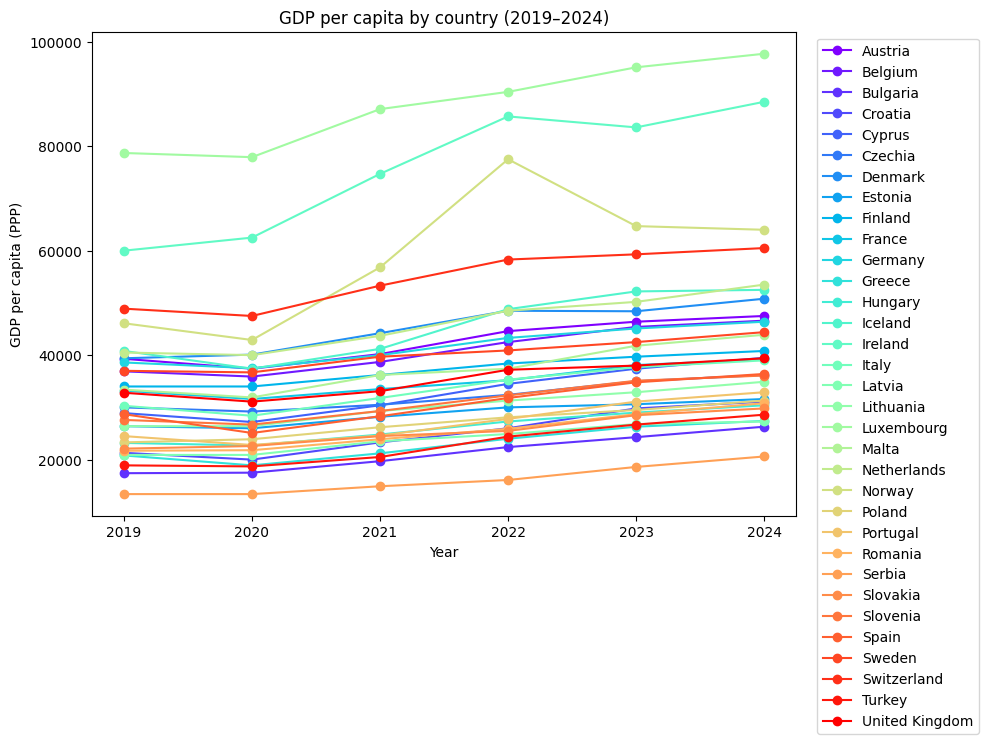

In [26]:
# set plot size
plt.figure(figsize=(10,7))

countries = eu_gdp_and_to_ch_annual_plot_df["Visitors' country of residence"].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(countries)))

# get each country data 
for i, country in enumerate(countries):    
    
    # filter out data for the target country
    country_data = eu_gdp_and_to_ch_annual_plot_df[eu_gdp_and_to_ch_annual_plot_df["Visitors' country of residence"] == country]
    
    # plot annual GDP from target country
    plt.plot(
        country_data["Year"],
        country_data["gdp_ppp"],
        marker="o",
        label=country,
        color=colors[i]
    )

# set plot labels and annotations
plt.xlabel("Year")
plt.ylabel("GDP per capita (PPP)")
plt.title("GDP per capita by country (2019–2024)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# plot
plt.tight_layout()
plt.show()

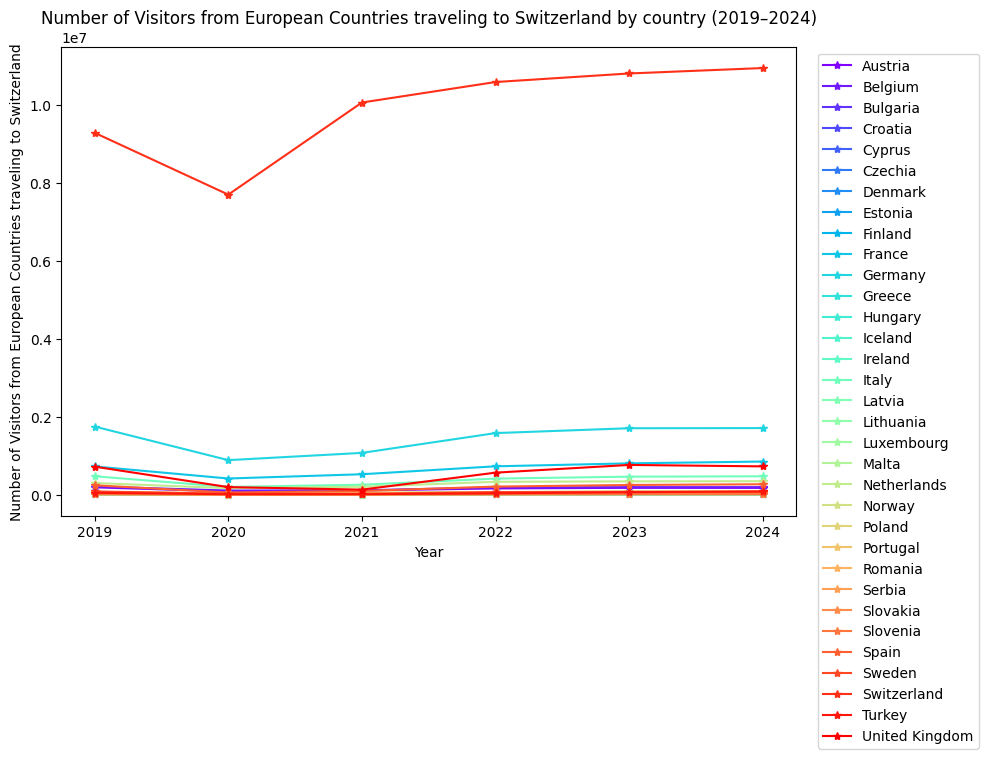

In [27]:
# set plot size
plt.figure(figsize=(10,7))

# get each country data 
for i, country in enumerate(countries):    

    # filter out data for the target country
    country_data = eu_gdp_and_to_ch_annual_plot_df[eu_gdp_and_to_ch_annual_plot_df["Visitors' country of residence"] == country]

    # plot yearly number of visitors from target country to Switzerland
    plt.plot(
        country_data["Year"],
        country_data["num_of_visitors"],
        marker="*",
        label=country,
        color=colors[i]
    )


# set plot labels and annotations
plt.xlabel("Year")
plt.ylabel("Number of Visitors from European Countries traveling to Switzerland")
plt.title("Number of Visitors from European Countries traveling to Switzerland by country (2019–2024)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# plot
plt.tight_layout()
plt.show()